# Imports

In [1]:
pip install lxml

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
from lxml import etree
import pandas as pd
import os
from IPython.display import clear_output
from tqdm import tqdm
from shutil import copyfile
import datetime

# Sélection des séances

Voici deux fonctions qui retiennent la liste des séances ayant un point lié aux VSS dans leur sommaire, ou 3 références au champ lexical des VSS dans leur texte.

In [4]:
def tri_titres(fichier, liste):
    """
        Pour un fichier de débats à l'assemblée, teste s'il a ou non un titre spécifique dans son sommaire.
        input : un nom de fichier .xml au format str et une liste de chaines de caractères
        output : un booléen True si le sommaire comprend une des expressions
    """
    root=etree.parse(fichier).getroot()
    yes=False
    for chaine in liste:
        for titre1 in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}metadonnees/{http://schemas.assemblee-nationale.fr/referentiel}sommaire/{http://schemas.assemblee-nationale.fr/referentiel}sommaire1/{http://schemas.assemblee-nationale.fr/referentiel}titreStruct/{http://schemas.assemblee-nationale.fr/referentiel}intitule"):
            #print(titre1.text)
            if chaine in titre1.text.lower():
                yes=True
                break
        for titre2 in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}metadonnees/{http://schemas.assemblee-nationale.fr/referentiel}sommaire/{http://schemas.assemblee-nationale.fr/referentiel}sommaire1/{http://schemas.assemblee-nationale.fr/referentiel}sommaire2/{http://schemas.assemblee-nationale.fr/referentiel}titreStruct/{http://schemas.assemblee-nationale.fr/referentiel}intitule"):
            #print(titre2.text)
            if titre2.text!=None and chaine in titre2.text.lower():
                yes=True
                break
    return yes
    

In [5]:
def tri_textes(fichier, liste, seuil):
    """
        Pour un fichier de débats à l'assemblée, teste s'il a un certain nombre d'expressions d'une liste renseignée dans le texte.
        input : un nom de fichier .xml au format str, une liste de chaines à tester, un nombre d'occurences à partir duquel on garde le texte
        output : un booléen True si le texte comprend n_occurrences expressions

        attention : l'apostrophe est notée "’" dans les débats
    """
    root=etree.parse(fichier).getroot()
    yes=False
    nb_occurences=0
    for chaine in liste:
        for i in root.findall("{http://schemas.assemblee-nationale.fr/referentiel}contenu/{http://schemas.assemblee-nationale.fr/referentiel}point/{http://schemas.assemblee-nationale.fr/referentiel}paragraphe") + root.findall("{http://schemas.assemblee-nationale.fr/referentiel}contenu/{http://schemas.assemblee-nationale.fr/referentiel}point/{http://schemas.assemblee-nationale.fr/referentiel}interExtraction/{http://schemas.assemblee-nationale.fr/referentiel}paragraphe"):
            if chaine in ''.join(i.findall("{http://schemas.assemblee-nationale.fr/referentiel}texte")[0].itertext()).lower():
                nb_occurences+=1
            
    if nb_occurences >= seuil:
        yes=True
    return yes

In [6]:
a_tester=["violences sexistes", "violences sexuelles", "violences conjugales", "violences faites aux femmes", "féminicide", "viol ", "viols", "harcèlement sexuel", "inceste"]
liste_pertinente=[] # liste des fichiers contenant les termes de la liste a_tester
seuil=3 # Nombre de termes de la liste à avoir pour garder un texte

In [7]:
# Recherche dans la XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)

# Recherche dans la XVIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)


    # Recherche dans la XVIIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/")
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        if tri_titres(file.name, a_tester)==True:
            liste_pertinente.append(file.name)
        if tri_textes(file.name, a_tester, seuil)==True:
            liste_pertinente.append(file.name)

liste_pertinente=list(set(liste_pertinente)) # on enlève les doublons

1564it [00:46, 33.29it/s]
605it [00:23, 26.11it/s]
365it [00:13, 27.76it/s]


In [8]:
# Nombre de séances retenues
len(liste_pertinente)

211

## Ajout des séances retenues dans un dossier séparé

In [9]:
# XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXV/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xv/" + file.name)

# XVIe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVI/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xvi/" + file.name)

# XVe législature
if os.getcwd() !="/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/":
    os.chdir("/home/onyxia/work/projet_eco_socio/data/CompteRendusXVII/")
for file in tqdm(os.scandir()):
    if file.name in liste_pertinente:
        copyfile(file.name, "/home/onyxia/work/projet_eco_socio/sorted/xvii/" + file.name)

1564it [00:00, 7150.58it/s]
605it [00:00, 5844.04it/s]
365it [00:00, 5596.19it/s]


Objectif : pour chaque document traité, obtenir le sommaire. Cela permet de trier entre les documents qui abordent des thématiques qui nous intéressent (les violences sexistes et sexuelles) et ceux qui n'ont pas d'intérêt dans notre analyse.

# Parsing des débats à l'Assemblée Nationale

La fonction ci-dessous crée un dataframe regroupant les textes des débats, avec quelques informations complémentaires (date, législature...) et les id des députés. Il est possible qu'elle ne parse pas parfaitement tous les débats, mais on peut rajouter des chemins dans la boucle for pour compléter les manques.

In [10]:
def parsing_debats(fichier):
    """
        Parse un fichier .xml de débats à l'Assemblée Nationale et crée un dataframe des prises de paroles, avec quelques informations complémentaires.
        input : un fichier.xml
        output : un dataframe Pandas
    """
    tree = etree.parse(fichier)
    root = tree.getroot()
    adresse = "{http://schemas.assemblee-nationale.fr/referentiel}"
    
    # Au lieu d'un DataFrame vide, on utilise une liste
    data_list = []
    
    # On récupère les infos communes à tout le fichier une seule fois
    uid_seance = root.findall(adresse + "uid")[0].text
    date_brute = root.findall(adresse + "metadonnees/" + adresse + "dateSeance")[0].text[:8]
    date_seance = pd.to_datetime(date_brute)
    legis = root.findall(adresse + "metadonnees/" + adresse + "legislature")[0].text

    # Ta boucle de recherche de paragraphes
    chemins = [
        adresse + "contenu/" + adresse + "point/" + adresse + "interExtraction/",
        adresse + "contenu/" + adresse + "point/" + adresse + "point/" + adresse + "interExtraction/",
        adresse + "contenu/" + adresse + "point/" + adresse + "paragraphe"
    ]
    
    nodes = []
    for chemin in chemins:
        nodes.extend(root.findall(chemin))

    for i in nodes:
        # Nettoyage du texte (ton code précédent)
        parts = []
        for j in i.findall(adresse + "texte"):
            if j.text: parts.append(j.text)
            for child in j:
                if not child.tag.endswith("italique") and child.text:
                    parts.append(child.text)
                if child.tail: parts.append(child.tail)
        
        texte_final = "".join(parts).replace("\xa0", " ")

        # On ajoute un dictionnaire à notre liste
        data_list.append({
            "seanceRef": uid_seance,
            "ordre_absolu_seance": i.get("ordre_absolu_seance"),
            "date": date_seance,
            "legislature": legis,
            "id_acteur": i.get("id_acteur"),
            "code_grammaire": i.get("code_grammaire"),
            "texte": texte_final
        })

    # On crée le DataFrame d'un seul coup à la fin (Plus de Warning !)
    df = pd.DataFrame(data_list)
    if not df.empty:
        df["ordre_absolu_seance"] = pd.to_numeric(df["ordre_absolu_seance"])
        df = df.sort_values(by="ordre_absolu_seance")
    
    return df

# Parsing des députés et partis politiques

On sélectionne les députés des 3 législatures qui nous intéressent, et leur appartenance politique.

In [11]:
adresse = "{http://schemas.assemblee-nationale.fr/referentiel}"

Les cellules suivantes ont été exécutées en local pour éviter d'importer des milliers de fichiers. Les résultats (fichiers des partis et des députés) sont disponibles dans les dossiers "partis" et "deputes".

In [12]:
# Tri des partis parmi les organes
os.chdir("/home/onyxia/work/projet_eco_socio/organes/")

for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        if root.findall(adresse + "codeType")[0].text=="PARPOL":
            copyfile(file.name, "/home/onyxia/work/projet_eco_socio/partis/" + file.name)


FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/organes/'

In [13]:
# Tri des législatures de l'Assemblée parmi les organes 
os.chdir("/home/onyxia/work/projet_eco_socio/organes/")

for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        if root.findall(adresse + "codeType")[0].text=="ASSEMBLEE":
            copyfile(file.name, "/home/onyxia/work/projet_eco_socio/assemblee/" + file.name)


FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/organes/'

In [14]:
# Tri des députés parmi les acteurs
os.chdir("/home/onyxia/work/projet_eco_socio/acteur")
liste_legislatures=["PO791932", "PO838901", "PO717460"]

for file in os.scandir():
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        for i in root.findall(adresse + "mandats/" + adresse + "mandat/" + adresse + "organes/" + adresse + "organeRef"):
            if i.text in liste_legislatures:
                copyfile(file.name, "/home/onyxia/work/projet_eco_socio/deputes/" + file.name)
                break

FileNotFoundError: [Errno 2] No such file or directory: '/home/onyxia/work/projet_eco_socio/acteur'

In [15]:
# DF des partis politiques
os.chdir("/home/onyxia/work/projet_eco_socio/partis/")
df_partis=pd.DataFrame({"parti":[], "nom_parti":[]})
df_partis["parti"]=df_partis["parti"].astype("str")

k=0
for file in tqdm(os.scandir()):
    if file.name[-3:]=="xml":
        tree=etree.parse(file.name)
        root=tree.getroot()
        df_partis.loc[k, "parti"]=root.findall(adresse + "uid")[0].text
        df_partis.loc[k, "nom_parti"]=root.findall(adresse + "libelle")[0].text
        k+=1


df_partis["parti"]=df_partis["parti"].astype("str")


0it [00:00, ?it/s]/tmp/ipykernel_2431/346939273.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Mouvement Indépendantiste Martiniquais' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_partis.loc[k, "nom_parti"]=root.findall(adresse + "libelle")[0].text
58it [00:00, 1190.96it/s]


In [16]:
# DF des députés
os.chdir("/home/onyxia/work/projet_eco_socio/deputes")
df_deputes=pd.DataFrame({"id_acteur":[], "nom":[], "prenom":[], "parti":[], "debut":[]})
df_deputes["parti"]=df_deputes["parti"].astype("str")

k=0
for file in os.scandir():
    tree=etree.parse(file.name)
    root=tree.getroot()
    for i in root.findall(adresse + "mandats/" + adresse + "mandat"):
        if i.findall(adresse + "typeOrgane")[0].text=="PARPOL":
            df_deputes.loc[k, "id_acteur"]=root.findall(adresse + "uid")[0].text
            df_deputes.loc[k, "nom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "nom")[0].text
            df_deputes.loc[k, "prenom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "prenom")[0].text
            df_deputes.loc[k, "parti"]=i.findall(adresse + "organes/" + adresse + "organeRef")[0].text
            df_deputes.loc[k, "debut"]=i.findall(adresse + "dateDebut")[0].text
            k+=1

df_deputes["parti"]=df_deputes["parti"].astype("str")
df_deputes["debut"]=pd.to_datetime(df_deputes["debut"])

/tmp/ipykernel_2431/1193967353.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'PA794658' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "id_acteur"]=root.findall(adresse + "uid")[0].text
/tmp/ipykernel_2431/1193967353.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Fait' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "nom"]=root.findall(adresse + "etatCivil/" + adresse + "ident/" + adresse + "nom")[0].text
/tmp/ipykernel_2431/1193967353.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Philippe' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_deputes.loc[k, "pre

OSError: Error reading file '.ipynb_checkpoints': Is a directory

In [ ]:
df_deputes=df_deputes.merge(df_partis, on="parti")

In [ ]:
df_deputes.to_csv("/home/onyxia/work/projet_eco_socio/dataframes/df_deputes.csv")

# Ajout des partis dans les dataframes des débats

Ici, on reprend la fonction créée précédemment pour générer le dataframe des discussions d'une séance. Pour chaque prise de parole, on joint le nom du député et son parti au moment de la séance.

In [ ]:
# Tests avec une séance au hasard
df_test=parsing_debats("/home/onyxia/work/projet_eco_socio/sorted/xvi/CRSANR5L16S2023O1N078.xml")

In [19]:
def ajouter_partis(df_debats, df_deputes):
    """
        Joint un dataframe représentant une séance de débats avec les partis politiques des députés au moment de la séance.
    """
    # on s'assure que la date de la séance est bien un objet Date
    date_seance = pd.to_datetime(df_debats.loc[0, "date"])

    # on filtre les députés présents
    concernes = df_deputes[df_deputes["id_acteur"].isin(df_debats["id_acteur"])].copy()
    
    # on force la colonne 'debut' en datetime juste avant la comparaison
    concernes["debut"] = pd.to_datetime(concernes["debut"], errors='coerce')
    
    # on compare (maintenant les deux côtés sont des Timestamps)
    # on garde que les mandats qui ont commencé AVANT ou LE JOUR de la séance
    concernes = concernes[concernes["debut"] <= date_seance]

    # on garde le mandat le plus récent pour chaque député
    concernes = concernes.sort_values("debut", ascending=False).drop_duplicates(subset="id_acteur", keep="first")

    
    df_debats = df_debats.merge(concernes[["parti", "nom_parti", "id_acteur"]], on="id_acteur", how="left")
    
    return df_debats
    
    

In [21]:
print(df_deputes.columns)

Index(['id_acteur', 'nom', 'prenom', 'parti', 'debut'], dtype='object')


In [22]:
#  on s'assure que les deux dataframes utilisent des chaînes de caractères pour la clé 'parti'
df_deputes["parti"] = df_deputes["parti"].astype(str)
df_partis["parti"] = df_partis["parti"].astype(str)

#  merge ET on l'assigne à df_deputes
df_deputes = df_deputes.merge(df_partis, on="parti", how="left")


print("Nouvelles colonnes :", df_deputes.columns.tolist())

Nouvelles colonnes : ['id_acteur', 'nom', 'prenom', 'parti', 'debut', 'nom_parti']


In [23]:
all_seances = []
dossiers = ["xv", "xvi", "xvii"]

for leg in dossiers:
    chemin = f"/home/onyxia/work/projet_eco_socio/sorted/{leg}/"
    
    # vérification si le dossier existe vraiment
    if not os.path.exists(chemin):
        print(f"Le dossier {chemin} n'existe pas.")
        continue

    for file in tqdm(os.scandir(chemin), desc=f"Parsing {leg}"):
        if file.name.endswith(".xml"):
            try:
                # 1. parsing du fichier
                df_temp = parsing_debats(file.path)
                
                # vérification : si le dataframe est vide, on passe au suivant
                if df_temp.empty:
                    continue
                
                # 2. ajout des partis
                df_temp = ajouter_partis(df_temp, df_deputes)
                
                # on ne garde que si le merge a fonctionné et qu'il reste des données
                if not df_temp.empty:
                    all_seances.append(df_temp)
                    
            except Exception as e:
                # Ici on affiche l'erreur pour comprendre pourquoi ça rate sur ce fichier
                print(f"❌ Erreur sur le fichier {file.name} : {e}")
                continue

# sécurité avant de concaténer
if len(all_seances) > 0:
    df_global = pd.concat(all_seances, ignore_index=True)
    print(f"Succès : {len(df_global)} prises de parole récupérées.")
else:
    print("Erreur : Aucun fichier n'a pu être traité. Vérifie tes chemins ou tes fonctions.")

Parsing xv: 158it [00:03, 49.74it/s]
Parsing xvi: 89it [00:02, 40.71it/s]
Parsing xvii: 50it [00:01, 40.87it/s]


✅ Succès ! 127710 prises de parole récupérées.


In [26]:
# on crée une expression régulière à partir de la liste de mots-clés
pattern = '|'.join(a_tester)

# on filtre : on ne garde que les lignes qui contiennent un de ces mots
df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()

In [27]:

output_dir = "/home/onyxia/work/projet_eco_socio/analyses_par_partis/"
os.makedirs(output_dir, exist_ok=True)

# on groupe par le nom du parti
for parti, group in df_vss.groupby("nom_parti"):
    # nettoyage du nom du parti pour le nom de fichier
    nom_propre = "".join(x for x in parti if x.isalnum() or x in "._- ").strip()
    
    with open(f"{output_dir}{nom_propre}.txt", "w", encoding="utf-8") as f:
        # on écrit chaque prise de parole dans le fichier
        for discours in group["texte"]:
            f.write(discours + "\n\n---\n\n")

print(f"Documents créés pour {len(df_vss['nom_parti'].unique())} partis.")

Documents créés pour 31 partis.


/tmp/ipykernel_2431/462852104.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")


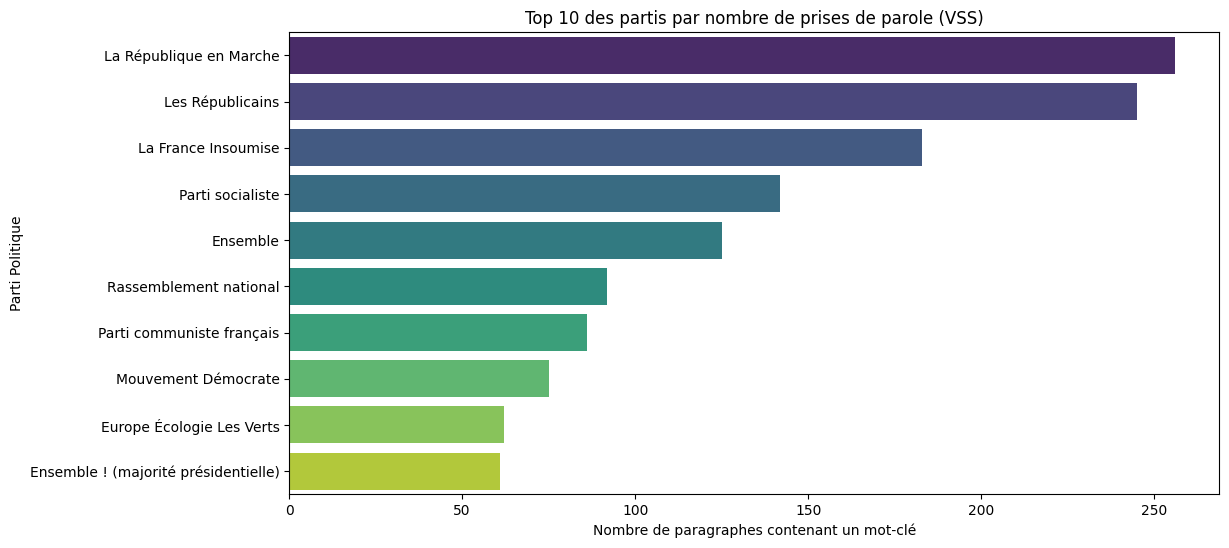

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# on s'assure d'avoir notre dataframe filtré avec uniquement les lignes "VSS"
pattern = '|'.join(a_tester)
df_vss = df_global[df_global['texte'].str.contains(pattern, case=False, na=False)].copy()

# Calcul du nombre de prises de parole par parti
vss_counts = df_vss['nom_parti'].value_counts().head(10) # Top 10 des partis

plt.figure(figsize=(12, 6))
sns.barplot(x=vss_counts.values, y=vss_counts.index, palette="viridis")
plt.title("Top 10 des partis par nombre de prises de parole (VSS)")
plt.xlabel("Nombre de paragraphes contenant un mot-clé")
plt.ylabel("Parti Politique")
plt.show()

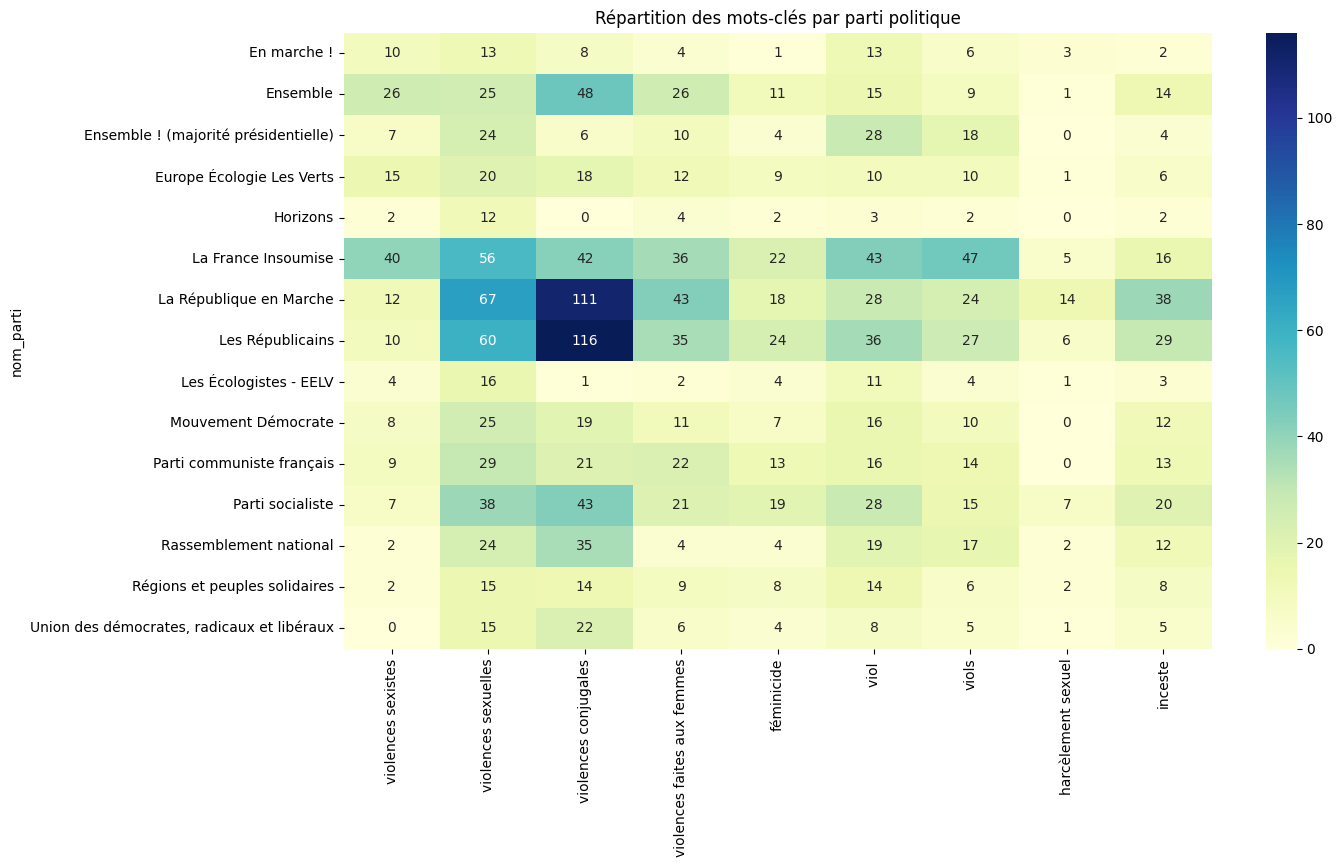

In [32]:
# on crée une colonne pour chaque mot-clé pour voir s'il est présent
for mot in a_tester:
    df_vss[mot] = df_vss['texte'].str.contains(mot, case=False, na=False)

# on regroupe par parti et on fait la somme des détections
heatmap_data = df_vss.groupby('nom_parti')[a_tester].sum()

# on ne garde que les partis qui ont au moins 10 mentions au total pour la lisibilité
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 10]

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='g')
plt.title("Répartition des mots-clés par parti politique")
plt.show()